<a href="https://colab.research.google.com/github/GowsikaRaja/jupyter-programs/blob/main/heart_disease_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split

df = pd.read_csv("heart.csv")
x = df.drop("target", axis=1)
y = df["target"]

x_train, x_test, y_train, y_test = train_test_split(
       x, y,test_size=0.2, random_state=42
)

In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)
dt.fit(x_train,y_train)

pred = dt.predict(x_test)
print(pred[:10])

[1 1 1]


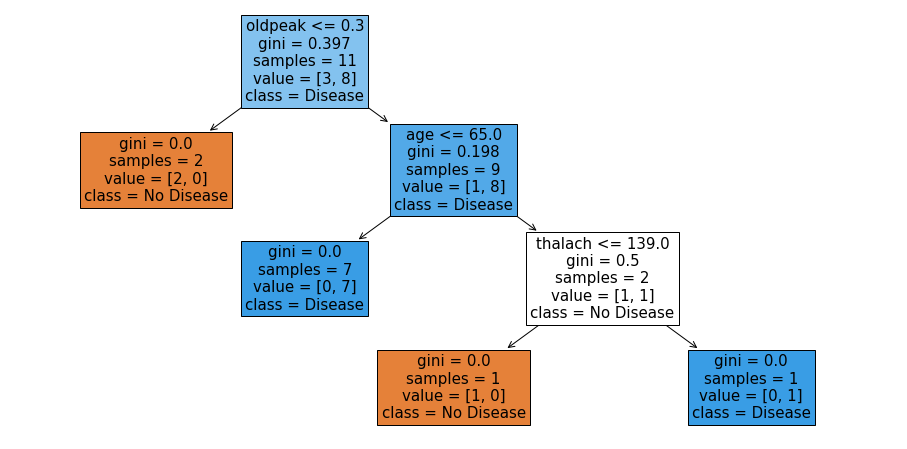

In [ ]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(16,8))
plot_tree(dt,feature_names=x.columns,class_names=["No Disease","Disease"], filled=True,max_depth=3,fontsize=15)
plt.show()

In [ ]:
for depth in [2,3,4,5,None]:
    dt_d=DecisionTreeClassifier(
    max_depth=depth,random_state=42
)
    dt_d.fit(x_train,y_train)
    train_acc = dt_d.score(x_train,y_train)
    test_acc=dt_d.score(x_test,y_test)
    print(depth,train_acc,test_acc)

2 0.9090909090909091 0.6666666666666666
3 1.0 0.6666666666666666
4 1.0 0.6666666666666666
5 1.0 0.6666666666666666
None 1.0 0.6666666666666666


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf=RandomForestClassifier(
   n_estimators=100,random_state=42
)
rf.fit(x_train,y_train)
pred_rf=rf.predict(x_test)

oldpeak     0.228881
age         0.179233
thalach     0.159601
trestbps    0.134337
chol        0.109453
exang       0.068890
sex         0.046413
ca          0.038418
cp          0.032493
fbs         0.002280
dtype: float64


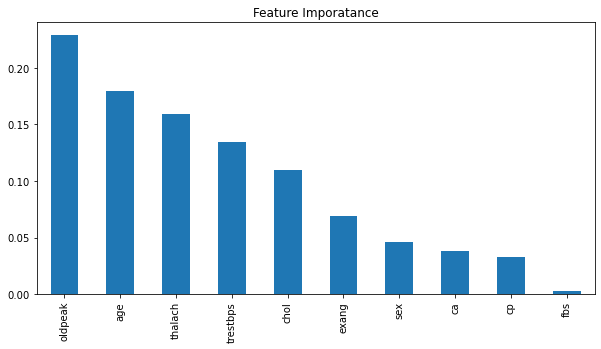

In [ ]:
importances = rf.feature_importances_
feat_imp = pd.Series(
    importances, index = x.columns
) .sort_values(ascending = False)
print(feat_imp)

feat_imp.plot(kind = "bar",figsize =(10,5))
plt.title("Feature Imporatance")
plt.show()

In [ ]:
for n in[50, 100, 200]:
    for depth in[3,5,None]:
        rf_t= RandomForestClassifier(
        n_estimators=n, max_depth = depth,random_state =42
)
        rf_t.fit(x_train,y_train)
        acc=rf_t.score(x_test,y_test)
        print(n,depth,acc)

50 3 0.6666666666666666
50 5 0.6666666666666666
50 None 0.6666666666666666
100 3 0.6666666666666666
100 5 0.6666666666666666
100 None 0.6666666666666666
200 3 0.6666666666666666
200 5 0.6666666666666666
200 None 0.6666666666666666


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score

models={"LogisticRegression":LogisticRegression(max_iter=1000),
        "Knn":KNeighborsClassifier(n_neighbors = 5),
       "DecisionTree":DecisionTreeClassifier(random_state=42),
       "RandomForest":RandomForestClassifier(n_estimators=100,random_state=42)
       }
Results = []
for name ,m in models.items():
    m.fit(x_train,y_train)
    p = m.predict(x_test)
    Results.append([name,accuracy_score(y_test,p),precision_score(y_test,p),recall_score(y_test,p),f1_score(y_test,p),
        ])
    Comparison_df = pd.DataFrame(Results,columns = ["Model","Accuracy","Precision","Recall","f1score"])
    print(Comparison_df)

                Model  Accuracy  Precision  Recall  f1score
0  LogisticRegression  0.666667   0.666667     1.0      0.8
                Model  Accuracy  Precision  Recall  f1score
0  LogisticRegression  0.666667   0.666667     1.0      0.8
1                 Knn  0.333333   0.500000     0.5      0.5
                Model  Accuracy  Precision  Recall  f1score
0  LogisticRegression  0.666667   0.666667     1.0      0.8
1                 Knn  0.333333   0.500000     0.5      0.5
2        DecisionTree  0.666667   0.666667     1.0      0.8
                Model  Accuracy  Precision  Recall  f1score
0  LogisticRegression  0.666667   0.666667     1.0      0.8
1                 Knn  0.333333   0.500000     0.5      0.5
2        DecisionTree  0.666667   0.666667     1.0      0.8
3        RandomForest  0.666667   0.666667     1.0      0.8
